In [1]:
import pandas as pd

In [2]:
df= pd.read_csv('Telco_customer_churn/Telco_Customer_Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isna().sum().sum()

0

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [7]:
df.isna().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

After changing Total Charges to numeric we got Nan values.

In [8]:
df["TotalCharges"] = df["TotalCharges"].fillna("0")
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.duplicated().sum()

0

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
df['churn_encode'] = df['Churn'].map({'Yes':1,'No':0})

In [13]:
numeric_column_data = df.select_dtypes(include=["number"]) 
numeric_column_data

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,churn_encode
0,0,1,29.85,29.85,0
1,0,34,56.95,1889.50,0
2,0,2,53.85,108.15,1
3,0,45,42.30,1840.75,0
4,0,2,70.70,151.65,1
...,...,...,...,...,...
7038,0,24,84.80,1990.50,0
7039,0,72,103.20,7362.90,0
7040,0,11,29.60,346.45,0
7041,1,4,74.40,306.60,1


In [14]:
numeric_column_data.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,churn_encode
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.150889
tenure,0.016567,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.103006,0.826178,0.651174,1.000000,-0.198324
churn_encode,0.150889,-0.352229,0.193356,-0.198324,1.000000


In [15]:
import matplotlib.pyplot as plt

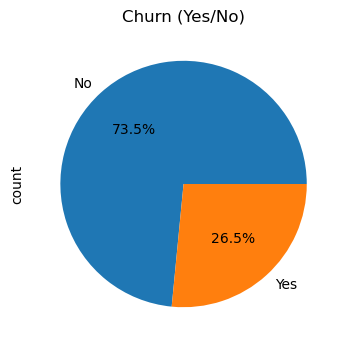

In [16]:
plt.figure(figsize=(5,4))
df["Churn"].value_counts().plot(kind="pie",autopct='%1.1f%%')
plt.title("Churn (Yes/No)")
plt.show()

In [17]:
df.groupby("Churn")["MonthlyCharges"].count()

Churn
No     5174
Yes    1869
Name: MonthlyCharges, dtype: int64

In [18]:
# from sklearn.linear_model import LogisticRegression

# # Encode categorical features
# X = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True)
# y = df['churn_encode']

# # Fit model
# model = LogisticRegression()
# model.fit(X, y)

# # Get coefficients
# importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
# importance.sort_values('Coefficient', key=abs, ascending=False).head(10)


In [19]:
df.groupby(["Churn","SeniorCitizen"])["MonthlyCharges"].mean()

Churn  SeniorCitizen
No     0                58.618123
       1                79.182057
Yes    0                72.298098
       1                80.713445
Name: MonthlyCharges, dtype: float64

In [20]:
df.groupby(["Churn"])["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

Early customers(customers who have recently joined) tends to churn more.

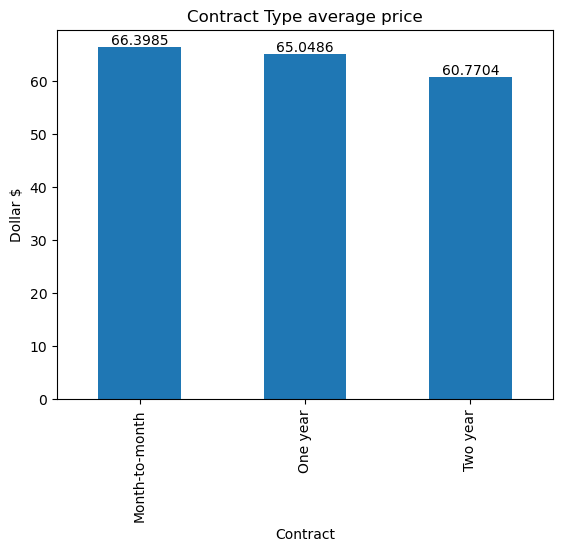

In [21]:

ax =df.groupby(["Contract"])["MonthlyCharges"].mean().plot(kind='bar')
plt.ylabel("Dollar $")
plt.title("Contract Type average price")
ax.bar_label(ax.containers[0])
plt.show()

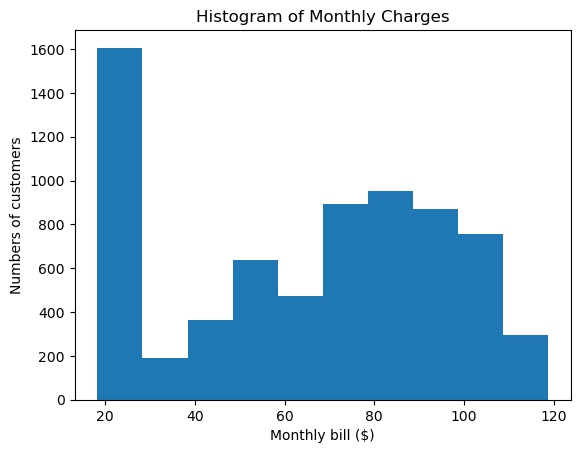

In [22]:
plt.hist(df['MonthlyCharges'])
plt.title("Histogram of Monthly Charges")
plt.ylabel("Numbers of customers")
plt.xlabel("Monthly bill ($)")
plt.show()

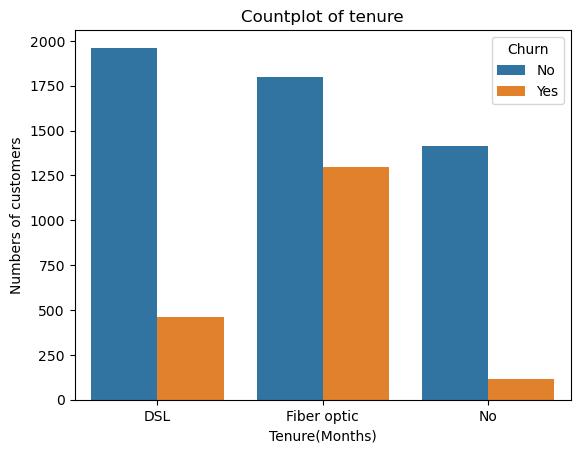

In [23]:
import seaborn as sns
sns.countplot(data=df,x='InternetService',hue='Churn')
plt.title("Countplot of tenure")
plt.ylabel("Numbers of customers")
plt.xlabel("Tenure(Months)")
plt.show()

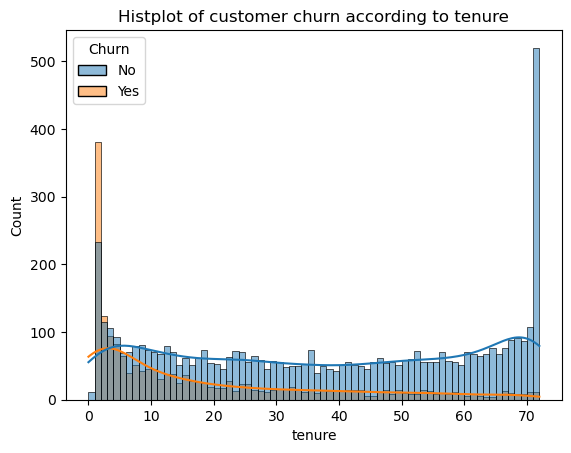

In [24]:
sns.histplot(data=df,x="tenure",hue='Churn',bins=72,kde=True)
plt.title("Histplot of customer churn according to tenure")
plt.show()

Costumers are more likely to leave in 1 to 2 years time frame.

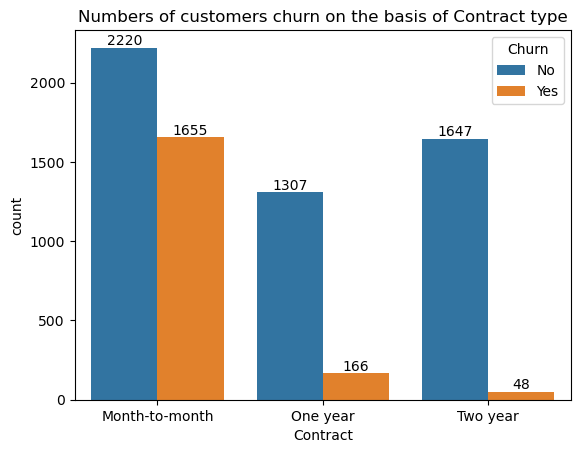

In [25]:
ax=sns.countplot(data=df,x='Contract',hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Numbers of customers churn on the basis of Contract type")
plt.show()

Customers having monthly contracts are more likely to churn out.

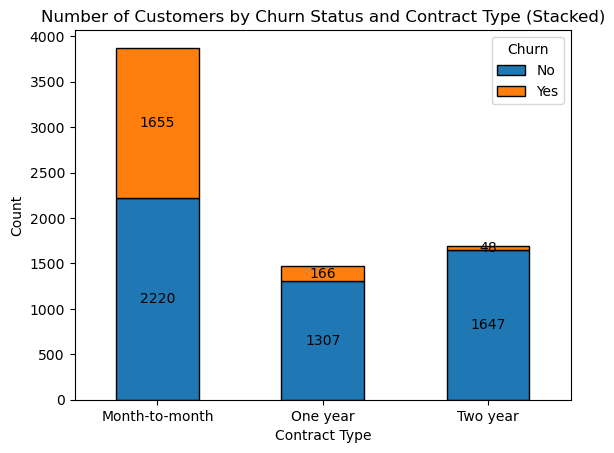

In [26]:
ax = sns.countplot(data=df, x='Contract', hue='Churn', palette=['#1f77b4', '#ff7f0e'])

# 2. Get counts for stacking
count_data = pd.crosstab(df['Contract'], df['Churn'])

# 3. Clear the current plot and create stacked bars
plt.cla()  # Clear the existing countplot
count_data.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'], edgecolor='black')

# 4. Add labels to each segment
for container in ax.containers:
    ax.bar_label(container, label_type='center')  # Center labels in each segment

# 5. Customize the plot
plt.title("Number of Customers by Churn Status and Contract Type (Stacked)")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(title='Churn')
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.show()

In [27]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'churn_encode'],
      dtype='object')

In [28]:
selected_columns = [
    'SeniorCitizen', 'tenure', 'InternetService',
    'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges'
]
X= df[selected_columns]
y=df[['Churn']]

y['Churn']=y['Churn'].apply(lambda x:1 if x=="Yes" else 0)


C:\Users\Kshitij\AppData\Local\Temp\ipykernel_8392\3145791682.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Churn']=y['Churn'].apply(lambda x:1 if x=="Yes" else 0)


In [29]:
X.head(2)

,SeniorCitizen,tenure,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges
0,0,1,DSL,Month-to-month,Electronic check,29.85,29.85
1,0,34,DSL,One year,Mailed check,56.95,1889.50


In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.9,test_size=0.1,stratify=y,random_state=0)


In [31]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
import joblib
cat_columns=['InternetService','Contract','PaymentMethod']
# cat_columns=['gender','Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity','OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV','StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
O_encoder = OrdinalEncoder()
scaler = StandardScaler()

scaler_column = ["tenure","MonthlyCharges","TotalCharges"]
                
#Apply target encoder to each column with categorical data
O_cols_train = pd.DataFrame(O_encoder.fit_transform(X_train[cat_columns]),columns=O_encoder.get_feature_names_out(cat_columns),index=X_train.index)
O_cols_test = pd.DataFrame(O_encoder.transform(X_test[cat_columns]),columns=O_encoder.get_feature_names_out(cat_columns),index=X_test.index)
#dropping categorical values
num_X_train = X_train.drop(cat_columns,axis=1)
num_X_test = X_test.drop(cat_columns,axis=1)

 #Apply Standard Scaler to each column with numerical data
num_X_train_scaled = pd.DataFrame(scaler.fit_transform(num_X_train[scaler_column]),columns=num_X_train[scaler_column].columns,index=num_X_train[scaler_column].index)

num_X_test_scaled=pd.DataFrame(scaler.transform(num_X_test[scaler_column]),columns=num_X_test[scaler_column].columns,index=num_X_test[scaler_column].index)

#Joblib to save scaler and OHE to file
joblib.dump(scaler,"scaler.pkl")
joblib.dump(O_encoder,"oh_encoder.pkl")

# Add one-hot encoded columns to numerical features
OH_X_train = pd.concat([num_X_train_scaled,O_cols_train,X_train['SeniorCitizen']],axis=1)
OH_X_test = pd.concat([num_X_test_scaled,O_cols_test,X_test['SeniorCitizen']],axis=1)
# Ensure all columns have string type
OH_X_train.columns = OH_X_train.columns.astype(str)
OH_X_test.columns = OH_X_test.columns.astype(str)

In [32]:
print(O_encoder.categories_)


[array(['DSL', 'Fiber optic', 'No'], dtype=object), array(['Month-to-month', 'One year', 'Two year'], dtype=object), array(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'], dtype=object)]


In [33]:
# from sklearn.preprocessing import TargetEncoder, StandardScaler
# import pandas as pd
# import joblib

# cat_columns = ['InternetService','Contract','PaymentMethod']
# scaler_column = ["tenure","MonthlyCharges","TotalCharges"]

# # Initialize encoders (keeping your original variable names)
# O_encoder = TargetEncoder(smooth="auto")  # TargetEncoder instead of OneHot
# scaler = StandardScaler()

# # Apply Target Encoder to categorical columns
# O_cols_train = pd.DataFrame(
#     O_encoder.fit_transform(X_train[cat_columns], y_train["Churn"]),  # y_train passed here
#     columns=O_encoder.get_feature_names_out(cat_columns),  # Keeps original column naming style
#     index=X_train.index
# )

# O_cols_test = pd.DataFrame(
#     O_encoder.transform(X_test[cat_columns]),
#     columns=O_encoder.get_feature_names_out(cat_columns),
#     index=X_test.index
# )

# # Process numerical columns (unchanged from your original)
# num_X_train = X_train.drop(cat_columns, axis=1)
# num_X_test = X_test.drop(cat_columns, axis=1)

# num_X_train_scaled = pd.DataFrame(
#     scaler.fit_transform(num_X_train[scaler_column]),
#     columns=num_X_train[scaler_column].columns,
#     index=num_X_train[scaler_column].index
# )

# num_X_test_scaled = pd.DataFrame(
#     scaler.transform(num_X_test[scaler_column]),
#     columns=num_X_test[scaler_column].columns,
#     index=num_X_test[scaler_column].index
# )

# # Save encoders (keeping your original filenames)
# joblib.dump(scaler, "scaler.pkl")
# joblib.dump(O_encoder, "oh_encoder.pkl")  # Note: Still called oh_encoder.pkl as in your original

# # Combine features (unchanged from your original)
# OH_X_train = pd.concat([num_X_train_scaled, O_cols_train, X_train['SeniorCitizen']], axis=1)
# OH_X_test = pd.concat([num_X_test_scaled, O_cols_test, X_test['SeniorCitizen']], axis=1)

# # Ensure string columns (unchanged)
# OH_X_train.columns = OH_X_train.columns.astype(str)
# OH_X_test.columns = OH_X_test.columns.astype(str)

In [34]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

def modelperformance(predictions):
    # print("Accuracy score on model is{}".format(accuracy_score(y_test,predictions)))
    # print(confusion_matrix(y_test, predictions))
    print(classification_report(y_test, predictions))


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')
log_model = LogisticRegression()

In [36]:
y_train = y_train.iloc[:,0]
y_test = y_test.iloc[:,0]

In [37]:
log_model.fit(OH_X_train,y_train)

LogisticRegression()

In [38]:
OH_X_train

,tenure,MonthlyCharges,TotalCharges,InternetService,Contract,PaymentMethod,SeniorCitizen
5402,-0.948247,-1.471611,-0.917772,2.0,2.0,3.0,0
1000,-1.029738,1.019508,-0.710645,1.0,0.0,2.0,0
2384,0.640814,0.876684,0.924969,1.0,0.0,1.0,1
6752,-0.826012,-0.491771,-0.758613,0.0,2.0,3.0,0
2578,-0.051854,1.137421,0.281521,1.0,0.0,2.0,1
...,...,...,...,...,...,...,...
3095,-0.866757,0.669091,-0.610189,1.0,0.0,2.0,0
525,0.803794,0.883327,1.087015,1.0,1.0,2.0,0
346,-1.233463,0.855095,-0.927868,1.0,0.0,2.0,0
5748,-0.459306,1.168976,-0.123542,1.0,0.0,1.0,0


In [39]:
predictions=log_model.predict(OH_X_test)


In [40]:
modelperformance(predictions=predictions)


              precision    recall  f1-score   support

           0       0.83      0.90      0.87       518
           1       0.64      0.51      0.57       187

    accuracy                           0.79       705
   macro avg       0.74      0.70      0.72       705
weighted avg       0.78      0.79      0.79       705



In [41]:
from sklearn.neighbors import KNeighborsClassifier
param_grid = {
    "n_neighbors":[3,5,7,9],
    "weights":["uniform","distance"]
}
# param_grid={
#     'C': [0.1, 1, 10],           # Regularization strength
#     'penalty': ['l1', 'l2'],      # Regularization type
#     'solver': ['liblinear', 'saga'] 
# }


In [42]:
gridkn = GridSearchCV(estimator=KNeighborsClassifier(),param_grid=param_grid,cv=5,n_jobs=-1#use all CPU cores
                      )

In [43]:
gridkn.fit(OH_X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [44]:
gridkn.best_params_

{'n_neighbors': 9, 'weights': 'uniform'}

In [45]:
g_predict=gridkn.predict(OH_X_test)
modelperformance(g_predict)

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       518
           1       0.63      0.52      0.57       187

    accuracy                           0.79       705
   macro avg       0.73      0.70      0.71       705
weighted avg       0.78      0.79      0.78       705



In [46]:
from sklearn.svm import SVC

In [47]:
svm = SVC(probability=True,class_weight='balanced')
param_grid={
    "C":[0.01,0.1,0.3,0.5,0.8,1],
    "kernel":["linear","rbf","poly"]
}

In [48]:
gridsvc = GridSearchCV(svm,param_grid=param_grid,cv=5,n_jobs=-1)
gridsvc.fit(OH_X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(class_weight='balanced', probability=True),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 0.3, 0.5, 0.8, 1],
                         'kernel': ['linear', 'rbf', 'poly']})

In [49]:
gridsvc.best_params_

{'C': 1, 'kernel': 'poly'}

In [50]:
best_svc = gridsvc.best_estimator_  # Best model after grid search

# Predict probabilities
y_probs = best_svc.predict_proba(OH_X_test)[:, 1]
 
threshold=0.25
y_preds = (y_probs >= threshold).astype(int)

print(f"\nThreshold: {threshold}")
print(classification_report(y_test, y_preds))


Threshold: 0.25
              precision    recall  f1-score   support

           0       0.91      0.73      0.81       518
           1       0.51      0.80      0.62       187

    accuracy                           0.75       705
   macro avg       0.71      0.76      0.72       705
weighted avg       0.80      0.75      0.76       705



In [51]:
OH_X_test

,tenure,MonthlyCharges,TotalCharges,InternetService,Contract,PaymentMethod,SeniorCitizen
2776,-0.663031,0.320334,-0.482553,1.0,0.0,1.0,1
2246,-1.274209,1.255334,-0.956856,1.0,0.0,2.0,0
4350,0.029636,-0.667810,-0.357188,0.0,0.0,1.0,0
3604,0.233362,-1.496522,-0.685779,2.0,0.0,2.0,0
5038,-0.907502,-1.506486,-0.920373,2.0,1.0,3.0,0
...,...,...,...,...,...,...,...
2768,-0.826012,-1.493201,-0.886998,2.0,1.0,3.0,0
319,0.111127,0.891631,0.424830,1.0,0.0,1.0,0
5945,1.007520,1.017848,1.452574,1.0,0.0,1.0,1
6766,-0.744522,-1.491540,-0.865637,2.0,1.0,3.0,0


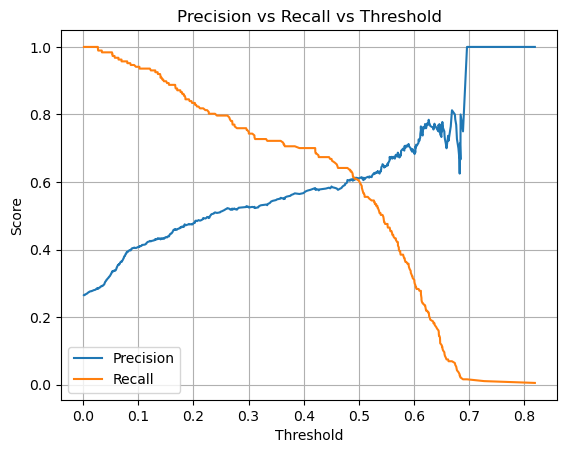

In [52]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


In [53]:
from sklearn.tree import DecisionTreeClassifier

In [54]:
parame_grid={
    "criterion":["gini","entropy"],
    "splitter":["best","random"],
    "max_depth":[None,5,10,15,20,30],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [55]:
gridtree = GridSearchCV(DecisionTreeClassifier(),param_grid=parame_grid,n_jobs=-1,cv=5)

In [56]:
gridtree.fit(OH_X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [57]:
gridtree.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'splitter': 'random'}

In [58]:
treePred = gridtree.predict(OH_X_test)
modelperformance(predictions=treePred)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       518
           1       0.65      0.51      0.57       187

    accuracy                           0.80       705
   macro avg       0.74      0.70      0.72       705
weighted avg       0.79      0.80      0.79       705



In [59]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier()

In [60]:
param_grid = {
    "n_estimators":[32,64,128,256],
    "max_features":[2,3,4],
    "bootstrap":[True,False]
}

In [61]:
gridrfc = GridSearchCV(estimator=rfc_model,cv=5,n_jobs=-1,param_grid=param_grid)

In [62]:
gridrfc.fit(OH_X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [32, 64, 128, 256]})

In [63]:
rfcpreds = gridrfc.predict(OH_X_test)
modelperformance(rfcpreds)

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       518
           1       0.61      0.48      0.53       187

    accuracy                           0.78       705
   macro avg       0.72      0.68      0.70       705
weighted avg       0.77      0.78      0.77       705



In [64]:
gridrfc.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 256}

In [68]:
best_model=best_svc

In [69]:
joblib.dump(best_model,"model.pkl")

['model.pkl']

In [70]:
OH_X_train.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'InternetService',
       'Contract', 'PaymentMethod', 'SeniorCitizen'],
      dtype='object')